### This file has Data Analytics in the inital part for EDA as well as for understanding the dataset, after which there is implementation of Machine Learning Techniques on this specific dataset.

### The original dataset is extensive and large in size, so only a 15,000-row subset was used. No further downloads are required for datasets.
### Complete dataset link https://openpaymentsdata.cms.gov/dataset/fb3a65aa-c901-4a38-a813-b04b00dfa2a9

### Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Loading Data and Pre-Processing

In [4]:
df=pd.read_csv('2023_General_Payment_Data.csv')

/var/folders/gl/gtqpk9s52v7_d3g5hfr_v3940000gn/T/ipykernel_4252/1079273054.py:1: DtypeWarning: Columns (18,34,35,69,75,81,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('2023_General_Payment_Data.csv')


In [5]:
df.head()

,Change_Type,Covered_Recipient_Type,Teaching_Hospital_CCN,Teaching_Hospital_ID,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_NPI,Covered_Recipient_First_Name,Covered_Recipient_Middle_Name,Covered_Recipient_Last_Name,...,Associated_Drug_or_Biological_NDC_4,Associated_Device_or_Medical_Supply_PDI_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Product_Category_or_Therapeutic_Area_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Associated_Drug_or_Biological_NDC_5,Associated_Device_or_Medical_Supply_PDI_5,Program_Year,Payment_Publication_Date
0,CHANGED,Covered Recipient Teaching Hospital,220162.0,9984.0,Adventhealth Orlando,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,01/30/2025
1,CHANGED,Covered Recipient Teaching Hospital,220162.0,9984.0,Carle Foundation Hospital,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,01/30/2025
2,CHANGED,Covered Recipient Teaching Hospital,220162.0,9984.0,St. Josephs Hospital & Medical Ctr,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,01/30/2025
3,CHANGED,Covered Recipient Teaching Hospital,220162.0,9984.0,St. Josephs Hospital & Medical Ctr,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,01/30/2025
4,CHANGED,Covered Recipient Teaching Hospital,220162.0,9984.0,Uc Davis Medical Center,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023,01/30/2025


In [6]:
df.columns

Index(['Change_Type', 'Covered_Recipient_Type', 'Teaching_Hospital_CCN',
       'Teaching_Hospital_ID', 'Teaching_Hospital_Name',
       'Covered_Recipient_Profile_ID', 'Covered_Recipient_NPI',
       'Covered_Recipient_First_Name', 'Covered_Recipient_Middle_Name',
       'Covered_Recipient_Last_Name', 'Covered_Recipient_Name_Suffix',
       'Recipient_Primary_Business_Street_Address_Line1',
       'Recipient_Primary_Business_Street_Address_Line2', 'Recipient_City',
       'Recipient_State', 'Recipient_Zip_Code', 'Recipient_Country',
       'Recipient_Province', 'Recipient_Postal_Code',
       'Covered_Recipient_Primary_Type_1', 'Covered_Recipient_Primary_Type_2',
       'Covered_Recipient_Primary_Type_3', 'Covered_Recipient_Primary_Type_4',
       'Covered_Recipient_Primary_Type_5', 'Covered_Recipient_Primary_Type_6',
       'Covered_Recipient_Specialty_1', 'Covered_Recipient_Specialty_2',
       'Covered_Recipient_Specialty_3', 'Covered_Recipient_Specialty_4',
       'Covered_Recipie

In [7]:
df.shape

(15000, 91)

In [8]:
df.isnull().sum()

Change_Type                                                     0
Covered_Recipient_Type                                          0
Teaching_Hospital_CCN                                       14869
Teaching_Hospital_ID                                        14869
Teaching_Hospital_Name                                      14869
                                                            ...  
Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5    14704
Associated_Drug_or_Biological_NDC_5                         14995
Associated_Device_or_Medical_Supply_PDI_5                   14998
Program_Year                                                    0
Payment_Publication_Date                                        0
Length: 91, dtype: int64

In [9]:
columns_of_interest_analysis = [
    'Teaching_Hospital_Name', 'Recipient_State', 'Total_Amount_of_Payment_USDollars',
    'Date_of_Payment', 'Form_of_Payment_or_Transfer_of_Value', 'Nature_of_Payment_or_Transfer_of_Value',
    'Covered_Recipient_Type', 'Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name',
    'Related_Product_Indicator', 'Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1',
    'Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1'
]
df=df[columns_of_interest_analysis]

In [10]:
# handling the missing values
df = df.dropna(subset=['Total_Amount_of_Payment_USDollars', 'Recipient_State'])

In [11]:
# converting Date_of_Payment to datetime
df['Date_of_Payment'] = pd.to_datetime(df['Date_of_Payment'], errors='coerce')

In [12]:
# cleaning the numerical data
df['Total_Amount_of_Payment_USDollars'] = pd.to_numeric(df['Total_Amount_of_Payment_USDollars'], errors='coerce')

In [13]:
# removing the invalid rows
df = df.dropna(subset=['Total_Amount_of_Payment_USDollars', 'Date_of_Payment'])

### Exploratory Data Analysis

In [14]:
# payment types distribution
payment_types = df['Nature_of_Payment_or_Transfer_of_Value'].value_counts().head(5)

In [15]:
print(payment_types)

Nature_of_Payment_or_Transfer_of_Value
Food and Beverage                                                                                                                                     12649
Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program      889
Consulting Fee                                                                                                                                          397
Entertainment                                                                                                                                           368
Travel and Lodging                                                                                                                                      225
Name: count, dtype: int64


In [16]:
# total payments by state
state_payments = df.groupby('Recipient_State')['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).head(10)

In [17]:
print(state_payments)

Recipient_State
MN    1365221.39
CA     727302.04
NY     590303.35
NJ     535599.02
GA     300925.75
FL     297569.33
IN     255915.13
OR     240761.59
TX     229838.08
MA     177294.43
Name: Total_Amount_of_Payment_USDollars, dtype: float64


In [18]:
# top manufacturers
top_manufacturers = df['Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name'].value_counts().head(5)

In [19]:
print(top_manufacturers)

Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name
Phadia US Inc.              3842
Evofem Biosciences, Inc.    1875
Minerva Surgical, Inc       1819
Neuronetics, Inc.           1157
Allergan, Inc.               984
Name: count, dtype: int64


In [20]:
# analysis of product type
product_types = df['Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1'].value_counts()

In [21]:
print(product_types)

Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1
Device            9056
Drug              3475
Biological          12
Medical Supply       1
Name: count, dtype: int64


### Graphs

In [22]:
sns.set_style("whitegrid")
colors = sns.color_palette("husl", 10)
fig = plt.figure(figsize=(18, 12), facecolor='#f5f5f5')

<Figure size 1800x1200 with 0 Axes>

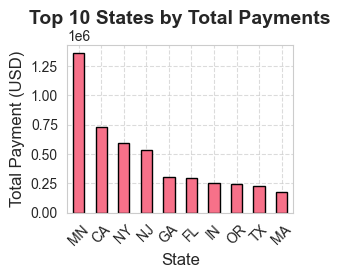

In [23]:
# Top 10 States by Total Payments
ax1 = plt.subplot(2, 2, 1)
state_payments.plot(kind='bar', ax=ax1, color=colors[0], edgecolor='black')
ax1.set_title('Top 10 States by Total Payments', fontsize=14, pad=15, weight='bold')
ax1.set_xlabel('State', fontsize=12)
ax1.set_ylabel('Total Payment (USD)', fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)

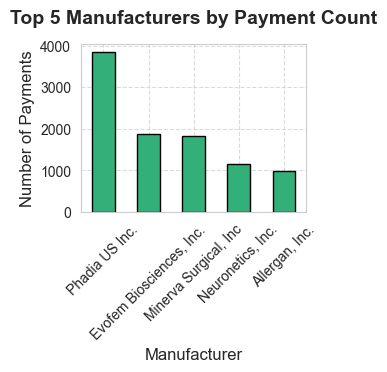

In [24]:
# Top Manufacturers
ax3 = plt.subplot(2, 2, 3)
top_manufacturers.plot(kind='bar', ax=ax3, color=colors[4], edgecolor='black')
ax3.set_title('Top 5 Manufacturers by Payment Count', fontsize=14, pad=15, weight='bold')
ax3.set_xlabel('Manufacturer', fontsize=12)
ax3.set_ylabel('Number of Payments', fontsize=12)
ax3.tick_params(axis='x', rotation=45, labelsize=10)
ax3.tick_params(axis='y', labelsize=10)
ax3.grid(True, linestyle='--', alpha=0.7)

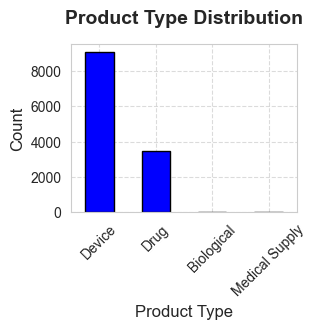

In [25]:
# Product Type Distribution
ax4 = plt.subplot(2, 2, 4)
product_types.plot(kind='bar', ax=ax4, color='blue', edgecolor='black')
ax4.set_title('Product Type Distribution', fontsize=14, pad=15, weight='bold')
ax4.set_xlabel('Product Type', fontsize=12)
ax4.set_ylabel('Count', fontsize=12)
ax4.tick_params(axis='x', rotation=45, labelsize=10)
ax4.tick_params(axis='y', labelsize=10)
ax4.grid(True, linestyle='--', alpha=0.7)

### <b>The goal of this project is to predict whether a payment exceeds a high-value threshold (e.g., $10,000) using machine learning models, specifically Random Forest and XGBoost. This binary classification problem will help stakeholders understand key factors driving high-value payments and assess the effectiveness of machine-learning methods on structured healthcare data. Due to computational constraints, a random sample of 15,000 rows from the 2023 General Payment Data has been used here.</b>

# Random Forest

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier

### Loading data and Pre-Processing

In [2]:
main_df = pd.read_csv('2023_General_Payment_Data.csv')
main_df_sample = main_df.sample(n=15000, random_state=42)

/var/folders/gl/gtqpk9s52v7_d3g5hfr_v3940000gn/T/ipykernel_2469/3417782670.py:1: DtypeWarning: Columns (18,34,35,69,75,81,87) have mixed types. Specify dtype option on import or set low_memory=False.
  main_df = pd.read_csv('2023_General_Payment_Data.csv')


In [28]:
# defining target variable
main_df_sample['High_Value_Payment'] = (main_df_sample['Total_Amount_of_Payment_USDollars'] > 10000).astype(int)

In [29]:
X = main_df_sample.drop(['High_Value_Payment', 'Total_Amount_of_Payment_USDollars'], axis=1)
y = main_df_sample['High_Value_Payment']

In [30]:
# identifying the categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [31]:
# Numerical preprocessing
scaler = StandardScaler()
X_numerical = scaler.fit_transform(X[numerical_cols])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [32]:
# Categorical preprocessing
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_categorical = encoder.fit_transform(X[categorical_cols])

In [33]:
# combining the preprocessed features
X_processed = np.hstack([X_numerical, X_categorical])

### Splitting the Data

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

### Training the model

In [35]:
randmom_forest_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
randmom_forest_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

### Testing the model

In [36]:
y_pred_rf = randmom_forest_model.predict(X_test)

### Performance Metrics

In [37]:
print("Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
rf_auc = roc_auc_score(y_test, randmom_forest_model.predict_proba(X_test)[:, 1])
print("AUC-ROC:", rf_auc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:
Accuracy: 0.993
Precision: 1.0
Recall: 0.08695652173913043
F1-Score: 0.16
AUC-ROC: 0.9953191862248252

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2977
           1       1.00      0.09      0.16        23

    accuracy                           0.99      3000
   macro avg       1.00      0.54      0.58      3000
weighted avg       0.99      0.99      0.99      3000



### Feature importance

In [38]:
feature_names = numerical_cols.tolist() + list(encoder.get_feature_names_out(categorical_cols))
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': randmom_forest_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

In [39]:
rf_importance

,feature,importance
30366,Product_Category_or_Therapeutic_Area_1_Oncology,0.036073
30550,Associated_Device_or_Medical_Supply_PDI_1_H787...,0.030014
2,Covered_Recipient_Profile_ID,0.019496
30085,Nature_of_Payment_or_Transfer_of_Value_Royalty...,0.017874
20449,Recipient_Primary_Business_Street_Address_Line...,0.017276
24120,Recipient_Zip_Code_08876-2519,0.015987
3,Covered_Recipient_NPI,0.015425
17,Record_ID,0.015348
29709,Applicable_Manufacturer_or_Applicable_GPO_Maki...,0.014240
29629,Applicable_Manufacturer_or_Applicable_GPO_Maki...,0.013168


In [40]:
sns.set(style="whitegrid", palette="deep", font_scale=1.2)

/var/folders/gl/gtqpk9s52v7_d3g5hfr_v3940000gn/T/ipykernel_4252/2466991005.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=rf_importance, palette='Blues_r')


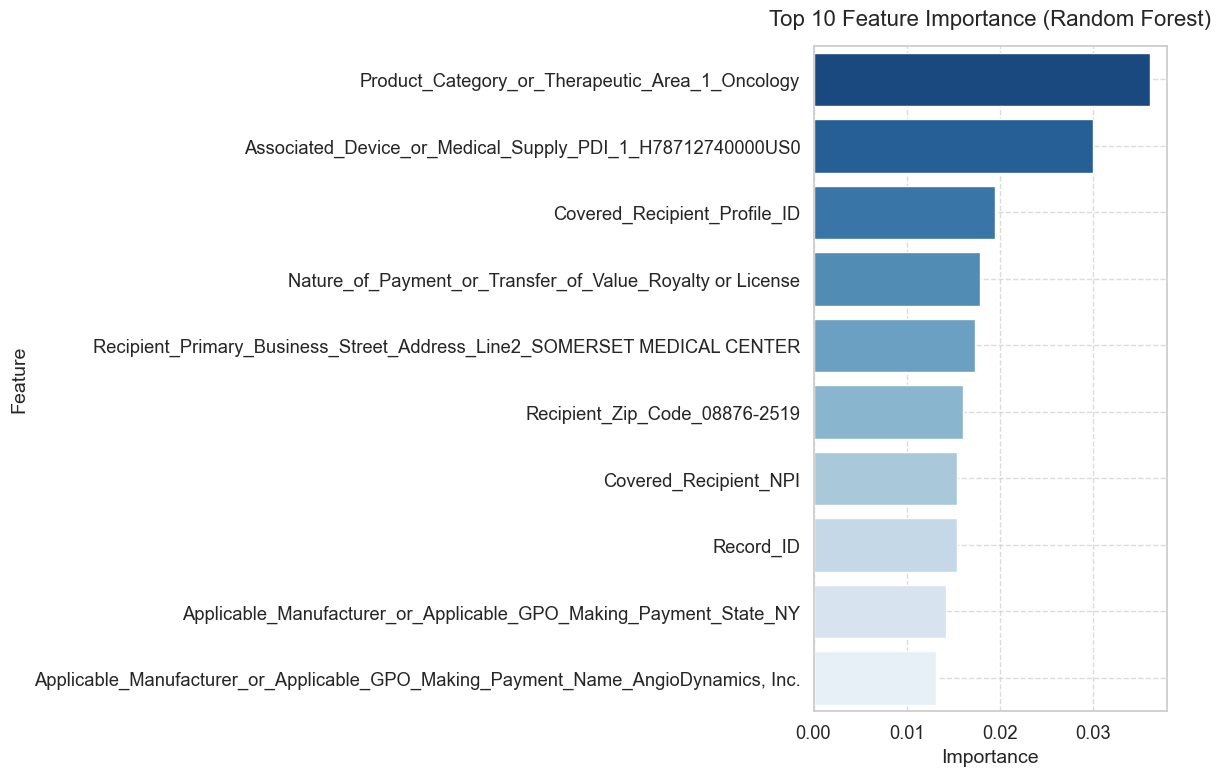

In [41]:
# Feature Importance for Random Forest
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=rf_importance, palette='Blues_r')
plt.title('Top 10 Feature Importance (Random Forest)', fontsize=16, pad=15)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

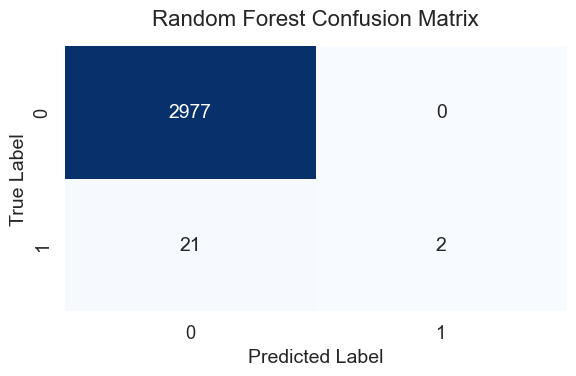

In [42]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={'size': 14})
plt.title('Random Forest Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

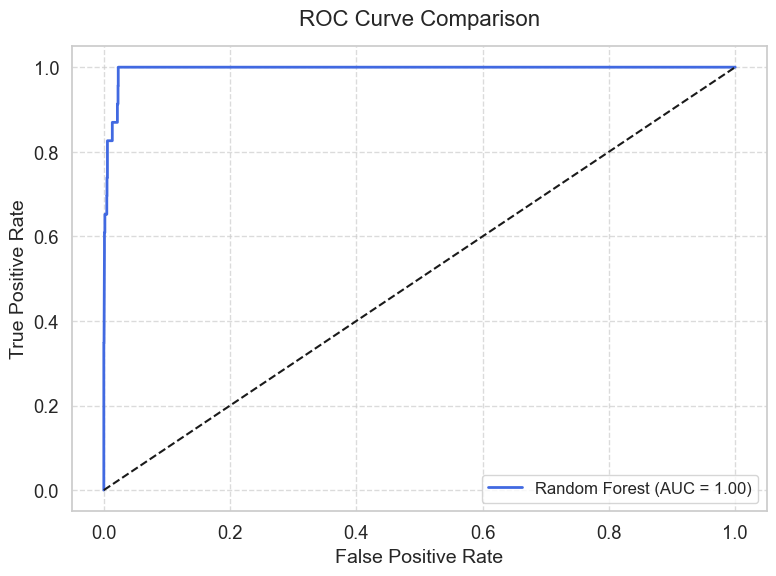

In [43]:
# ROC Curve for Random Forest
plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(y_test, randmom_forest_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})', linewidth=2, color='royalblue')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison', fontsize=16, pad=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# XGBoost

### Training the model of XGBoost

In [44]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

### Testing the XGBoost Model

In [45]:
y_pred_xgb = xgb_model.predict(X_test)

### Performance Metrics

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-Score:", f1_score(y_test, y_pred_xgb))
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print("AUC-ROC:", xgb_auc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.997
Precision: 0.85
Recall: 0.7391304347826086
F1-Score: 0.7906976744186046
AUC-ROC: 0.9990068788246119

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2977
           1       0.85      0.74      0.79        23

    accuracy                           1.00      3000
   macro avg       0.92      0.87      0.89      3000
weighted avg       1.00      1.00      1.00      3000



### Feature Importance

In [47]:
feature_names = numerical_cols.tolist() + list(encoder.get_feature_names_out(categorical_cols))
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

In [48]:
xgb_importance

,feature,importance
12467,Recipient_Primary_Business_Street_Address_Line...,0.504599
30555,Associated_Device_or_Medical_Supply_PDI_1_nan,0.101381
30080,Nature_of_Payment_or_Transfer_of_Value_Food an...,0.062895
30077,Nature_of_Payment_or_Transfer_of_Value_Consult...,0.042003
30085,Nature_of_Payment_or_Transfer_of_Value_Royalty...,0.031043
30391,Product_Category_or_Therapeutic_Area_1_Vascula...,0.030755
30076,Nature_of_Payment_or_Transfer_of_Value_Compens...,0.020452
30366,Product_Category_or_Therapeutic_Area_1_Oncology,0.018888
30395,Product_Category_or_Therapeutic_Area_1_nan,0.015703
7041,Covered_Recipient_Last_Name_GOULD,0.014411


In [49]:
sns.set(style="whitegrid", palette="deep", font_scale=1.2)

/var/folders/gl/gtqpk9s52v7_d3g5hfr_v3940000gn/T/ipykernel_4252/1927874590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=xgb_importance, palette='Reds_r')
/var/folders/gl/gtqpk9s52v7_d3g5hfr_v3940000gn/T/ipykernel_4252/1927874590.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


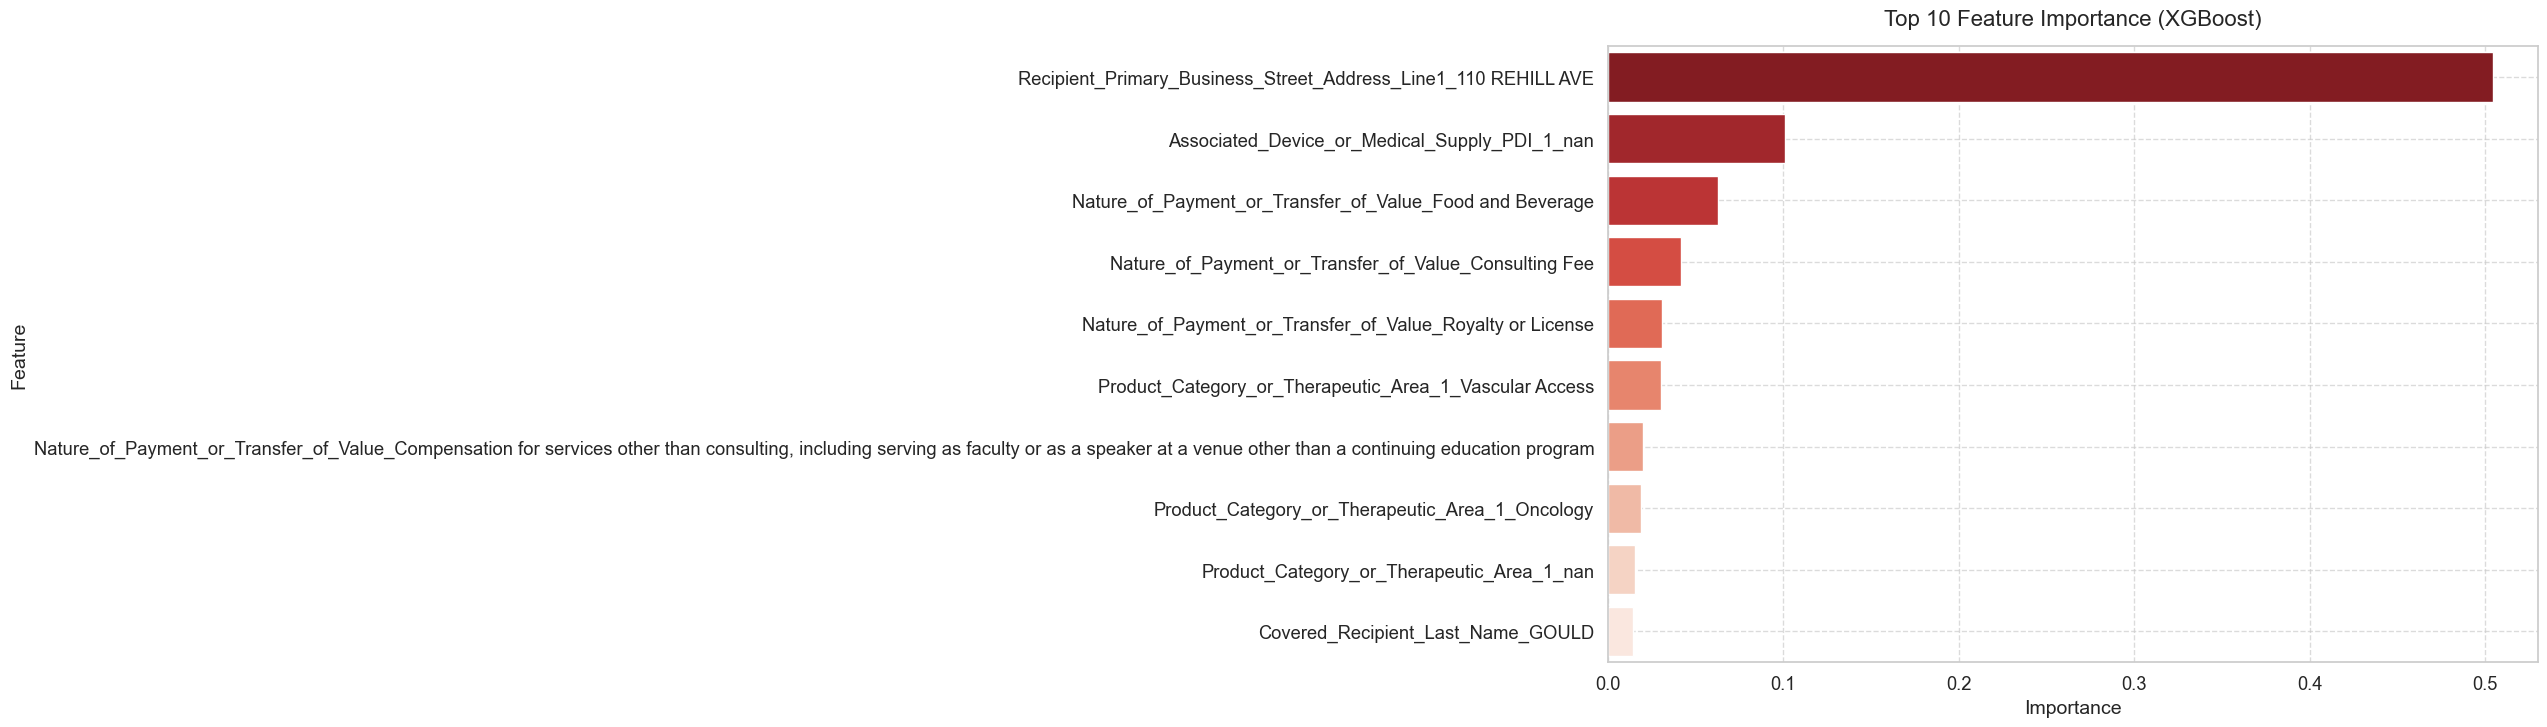

In [50]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=xgb_importance, palette='Reds_r')
plt.title('Top 10 Feature Importance (XGBoost)', fontsize=16, pad=15)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

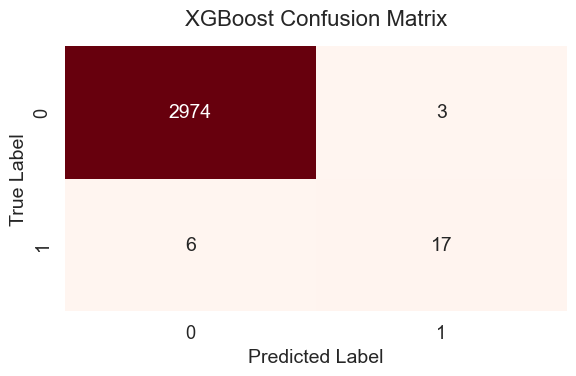

In [51]:
# Confusion Matrix for XGBoost
plt.figure(figsize=(6, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={'size': 14})
plt.title('XGBoost Confusion Matrix', fontsize=16, pad=15)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

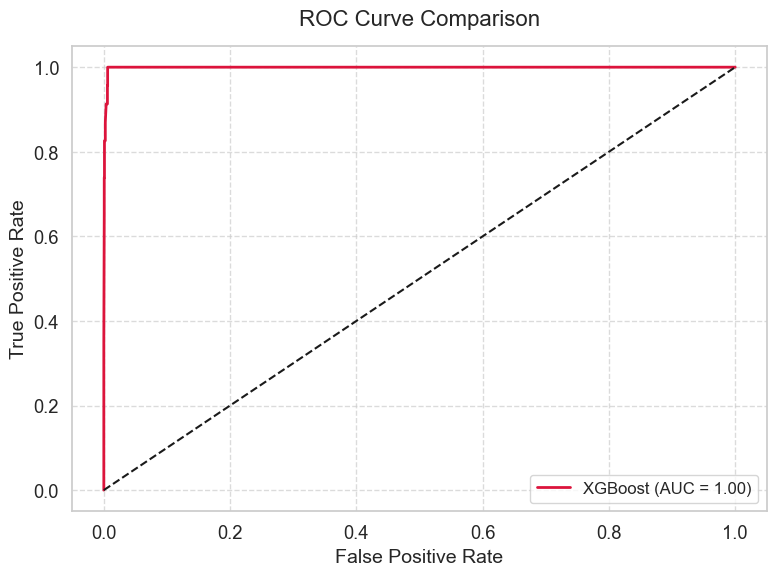

In [52]:
# ROC Curve for XGBoost
plt.figure(figsize=(8, 6))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.2f})', linewidth=2, color='crimson')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison', fontsize=16, pad=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Model Comparision

In [53]:
rf_cv_scores = cross_val_score(randmom_forest_model, X_processed, y, cv=5, scoring='roc_auc')
xgb_cv_scores = cross_val_score(xgb_model, X_processed, y, cv=5, scoring='roc_auc')
print("\nRandom Forest 5-Fold CV AUC-ROC: Mean =", rf_cv_scores.mean(), "Std =", rf_cv_scores.std())
print("XGBoost 5-Fold CV AUC-ROC: Mean =", xgb_cv_scores.mean(), "Std =", xgb_cv_scores.std())


Random Forest 5-Fold CV AUC-ROC: Mean = 0.9936795900537634 Std = 0.002290775189770484
XGBoost 5-Fold CV AUC-ROC: Mean = 0.992883125771814 Std = 0.009392690166130254


In [54]:
payment_amounts_test = main_df_sample.loc[y_test.index, 'Total_Amount_of_Payment_USDollars']

# creating a dataframe with test data
test_df = pd.DataFrame({
    'Payment_Amount_USD': payment_amounts_test.values,
    'Actual_Label': y_test.values,
    'RF_Predicted_Label': y_pred_rf,
    'XGB_Predicted_Label': y_pred_xgb,
    'Index': y_test.index
})

# selecting 5 samples each of label 0 and label 1 
label_0_samples = test_df[test_df['Actual_Label'] == 0].sample(n=min(5, len(test_df[test_df['Actual_Label'] == 0])), random_state=42)
label_1_samples = test_df[test_df['Actual_Label'] == 1].sample(n=min(5, len(test_df[test_df['Actual_Label'] == 1])), random_state=42)
comparison_df = pd.concat([label_0_samples, label_1_samples]).sort_index().head(10)

# adding columns to indicate if predictions are correct
comparison_df['Random_Forest_Correct'] = comparison_df['Actual_Label'] == comparison_df['RF_Predicted_Label']
comparison_df['XGB_Correct'] = comparison_df['Actual_Label'] == comparison_df['XGB_Predicted_Label']

# dropping the Index column for display
comparison_df = comparison_df.drop(columns=['Index'])

print("Predicted vs. Actual Comparison (10 Test Samples)")
print("-"*60)
print(comparison_df.to_string(index=False))
print("-"*60)
print("Note: Label 1 = Payment > $10,000 and Label 0 = Payment ≤ $10,000")
print("\n")

Predicted vs. Actual Comparison (10 Test Samples)
------------------------------------------------------------
 Payment_Amount_USD  Actual_Label  RF_Predicted_Label  XGB_Predicted_Label  Random_Forest_Correct  XGB_Correct
          105819.04             1                   0                    1                  False         True
              89.93             0                   0                    0                   True         True
              15.14             0                   0                    0                   True         True
           72857.26             1                   0                    1                  False         True
           52565.20             1                   0                    1                  False         True
              13.17             0                   0                    0                   True         True
           10948.70             1                   0                    1                  False         True
 

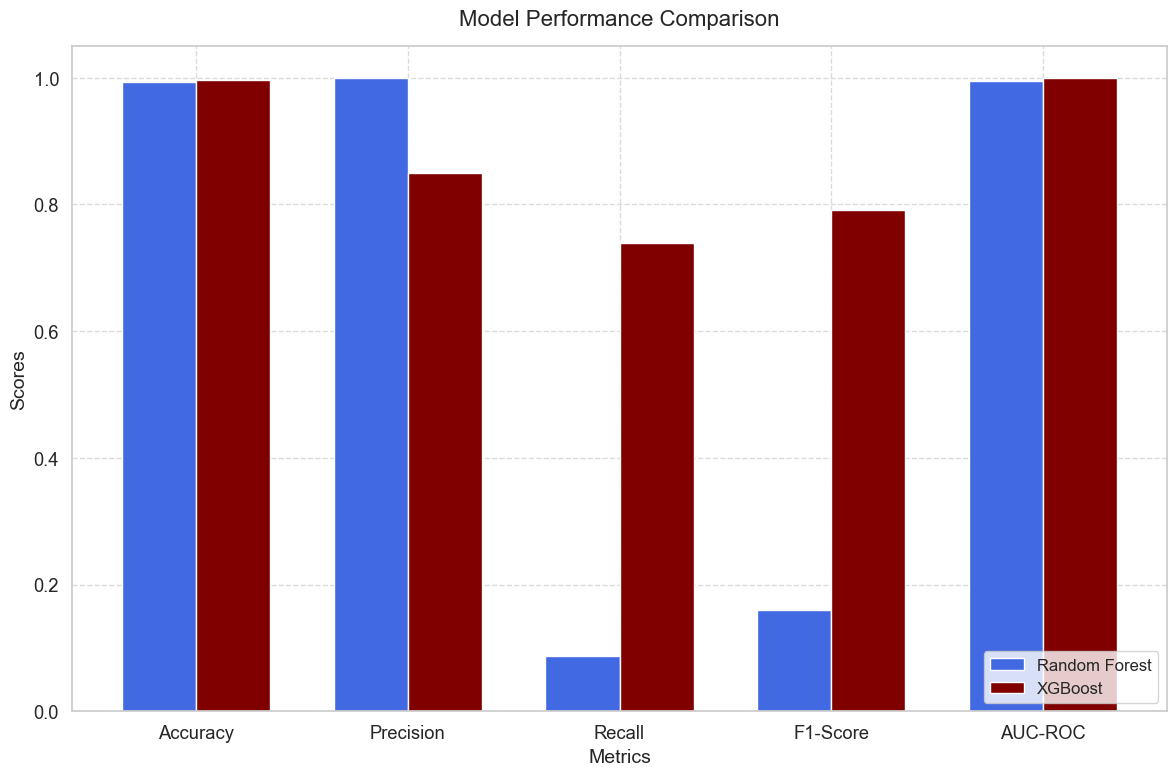

In [55]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
rf_metrics = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
              recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), rf_auc]
xgb_metrics = [accuracy_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb),
               recall_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb), xgb_auc]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(12, 8))
plt.bar(x - width/2, rf_metrics, width, label='Random Forest', color='royalblue')
plt.bar(x + width/2, xgb_metrics, width, label='XGBoost', color='maroon')
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Scores', fontsize=14)
plt.title('Model Performance Comparison', fontsize=16, pad=15)
plt.xticks(x, metrics)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()